<center><h1><span style="color: green;">THỰC HÀNH BUỔI 13.2</span></h1></center>

In [15]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import warnings
warnings.filterwarnings('ignore')

Mounted at /content/drive


# Ví dụ 1

## Cách 1: Tự xây dựng bằng thư viện numpy và cvxopt:

     pcost       dcost       gap    pres   dres
 0: -1.9569e+02 -3.9829e+02  2e+02  2e-15  5e-15
 1: -1.9724e+02 -2.0003e+02  3e+00  9e-16  6e-15
 2: -1.9781e+02 -1.9783e+02  3e-02  4e-15  6e-15
 3: -1.9781e+02 -1.9781e+02  3e-04  4e-16  5e-15
 4: -1.9781e+02 -1.9781e+02  3e-06  4e-15  5e-15
Optimal solution found.


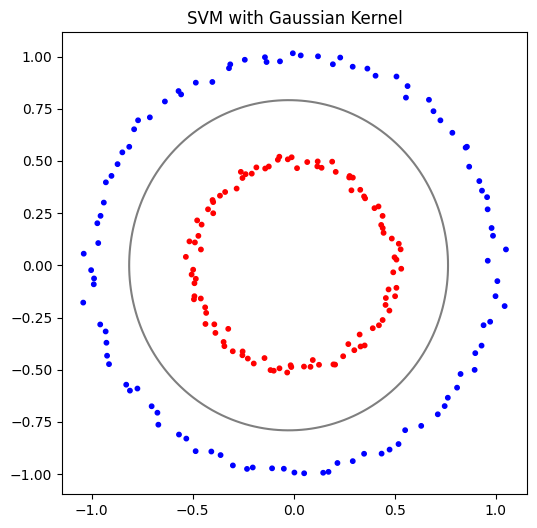

In [4]:
import numpy as np
from numpy import linalg
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
import cvxopt
import cvxopt.solvers

# Các kernel
def linear_kernel(x1, x2):
    return np.dot(x1, x2)

def polynomial_kernel(x, y, gamma=1, r=1, d=3):
    return (r + gamma * np.dot(x, y)) ** d

def gaussian_kernel(x, y, sigma=5.0):
    return np.exp(-linalg.norm(x - y) ** 2 / (2 * sigma ** 2))

# Lớp SVM
class SVM(object):
    def __init__(self, kernel=linear_kernel, C=None):
        self.kernel = kernel
        self.C = float(C) if C else None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        K = np.zeros((n_samples, n_samples))
        for i in range(n_samples):
            for j in range(n_samples):
                K[i,j] = self.kernel(X[i], X[j])
        P = cvxopt.matrix(np.outer(y, y) * K)
        q = cvxopt.matrix(-np.ones(n_samples))
        A = cvxopt.matrix(y, (1, n_samples), 'd')
        b = cvxopt.matrix(0.0)

        if self.C is None:
            G = cvxopt.matrix(-np.eye(n_samples))
            h = cvxopt.matrix(np.zeros(n_samples))
        else:
            G = cvxopt.matrix(np.vstack((-np.eye(n_samples), np.eye(n_samples))))
            h = cvxopt.matrix(np.hstack((np.zeros(n_samples), np.ones(n_samples) * self.C)))

        solution = cvxopt.solvers.qp(P, q, G, h, A, b)
        a = np.ravel(solution['x'])

        sv = a > 1e-5
        self.a = a[sv]
        self.sv = X[sv]
        self.sv_y = y[sv]

        self.b = np.mean([self.sv_y[i] - np.sum(self.a * self.sv_y * K[ind, sv])
                          for i, ind in enumerate(np.where(sv)[0])])

        if self.kernel == linear_kernel:
            self.w = np.sum([self.a[i] * self.sv_y[i] * self.sv[i] for i in range(len(self.a))], axis=0)
        else:
            self.w = None

    def project(self, X):
        if self.w is not None:
            return np.dot(X, self.w) + self.b
        else:
            return np.array([sum(a * y_sv * self.kernel(x, sv)
                        for a, y_sv, sv in zip(self.a, self.sv_y, self.sv)) + self.b for x in X])

    def predict(self, X):
        return np.sign(self.project(X))

# Tạo dữ liệu và huấn luyện
X, y = make_circles(n_samples=200, noise=0.02, factor=0.5)
y = np.where(y == 0, -1, 1)

clf = SVM(kernel=gaussian_kernel, C=1.0)
clf.fit(X, y)

# Vẽ kết quả
def plot_contour(clf, X, y):
    plt.figure(figsize=(6, 6))
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', s=10)
    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    XX, YY = np.meshgrid(np.linspace(*xlim, 100), np.linspace(*ylim, 100))
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    Z = clf.project(xy).reshape(XX.shape)

    ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])
    plt.title("SVM with Gaussian Kernel")
    plt.show()

plot_contour(clf, X, y)


## Cách 2: Dùng thư viện sklearn

Kernel: linear
Accuracy: 0.535
Confusion Matrix:
 [[41 59]
 [34 66]]


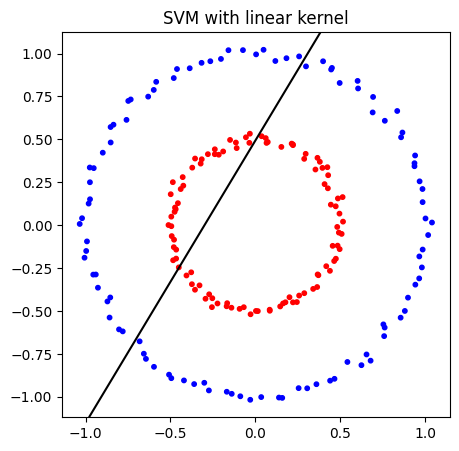

Kernel: sigmoid
Accuracy: 0.0
Confusion Matrix:
 [[  0 100]
 [100   0]]


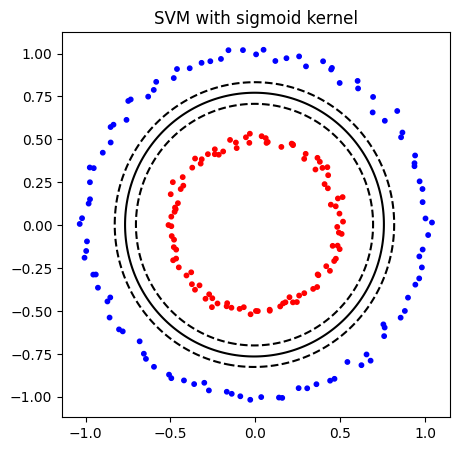

Kernel: poly
Accuracy: 1.0
Confusion Matrix:
 [[100   0]
 [  0 100]]


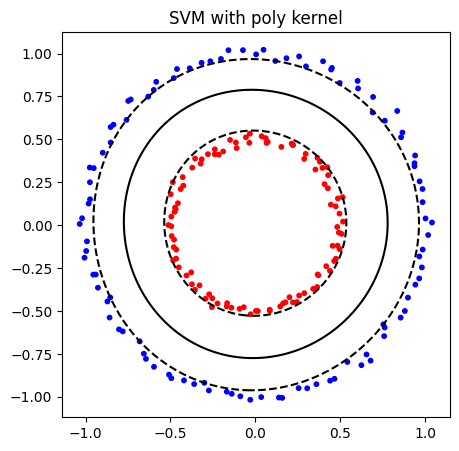

Kernel: rbf
Accuracy: 1.0
Confusion Matrix:
 [[100   0]
 [  0 100]]


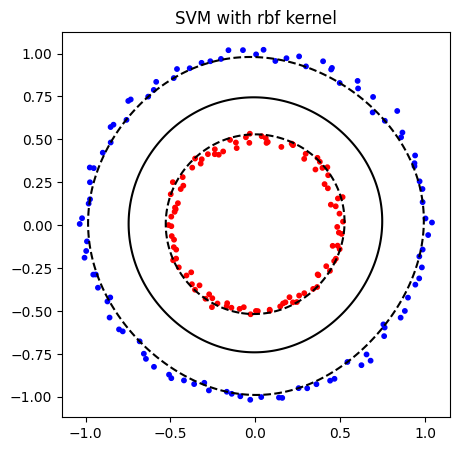

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.datasets import make_circles
from sklearn.metrics import confusion_matrix, accuracy_score

# Tạo dữ liệu
X, Y = make_circles(n_samples=200, noise=0.02, factor=0.5)

# Huấn luyện và đánh giá theo từng kernel
kernels = ['linear', 'sigmoid', 'poly', 'rbf']
for kernel in kernels:
    clf = svm.SVC(kernel=kernel, gamma=1, coef0=1)
    clf.fit(X, Y)
    y_pred = clf.predict(X)

    acc = accuracy_score(Y, y_pred)
    cm = confusion_matrix(Y, y_pred)

    print(f"Kernel: {kernel}")
    print("Accuracy:", acc)
    print("Confusion Matrix:\n", cm)

    # Vẽ biên phân lớp
    plt.figure(figsize=(5, 5))
    plt.scatter(X[:, 0], X[:, 1], c=Y, s=10, cmap='bwr')
    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    XX, YY = np.meshgrid(np.linspace(*xlim, 200), np.linspace(*ylim, 200))
    Z = clf.decision_function(np.c_[XX.ravel(), YY.ravel()])
    Z = Z.reshape(XX.shape)
    plt.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1],
                linestyles=['--', '-', '--'])
    plt.title(f"SVM with {kernel} kernel")
    plt.show()


# Bài tập 1


 SVM - linear kernel
Accuracy: 53.50%


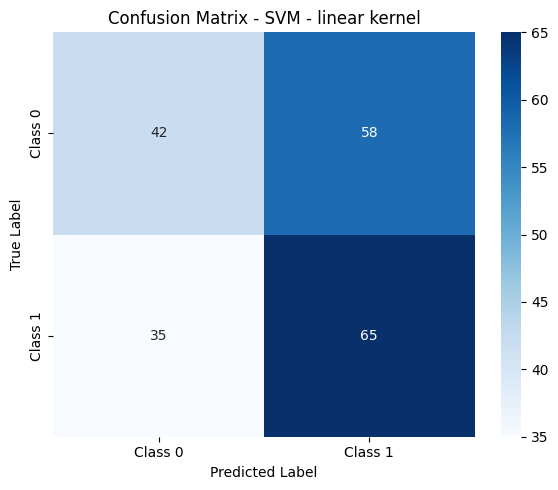


 SVM - sigmoid kernel
Accuracy: 0.00%


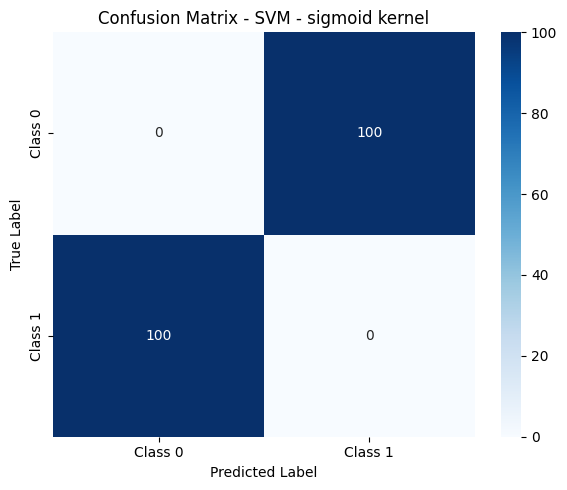


 SVM - poly kernel
Accuracy: 100.00%


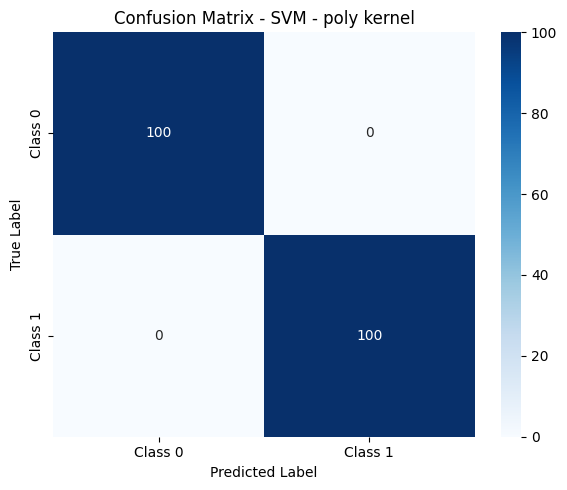


 SVM - rbf kernel
Accuracy: 100.00%


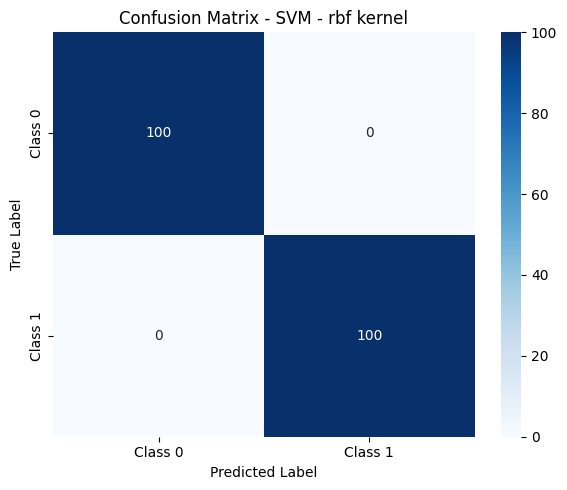

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import svm
from sklearn.datasets import make_circles
from sklearn.metrics import accuracy_score, confusion_matrix

# Hàm đánh giá và hiển thị
def evaluate_and_plot(y_true, y_pred, method_name=""):
    acc = accuracy_score(y_true.flatten(), y_pred)
    cm = confusion_matrix(y_true.flatten(), y_pred)

    print(f"\n {method_name}")
    print(f"Accuracy: {acc * 100:.2f}%")

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Class 0', 'Class 1'],
                yticklabels=['Class 0', 'Class 1'])
    plt.title(f'Confusion Matrix - {method_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

# Tạo dữ liệu
X, y = make_circles(n_samples=200, noise=0.02, factor=0.5)

# Huấn luyện và đánh giá theo từng kernel
kernels = ['linear', 'sigmoid', 'poly', 'rbf']

for kernel in kernels:
    clf = svm.SVC(kernel=kernel, gamma=1, coef0=1)
    clf.fit(X, y)
    y_pred = clf.predict(X)
    evaluate_and_plot(y, y_pred, method_name=f"SVM - {kernel} kernel")

# Ví dụ 2

### Kernel SVM với dữ liệu vi mạch

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import svm
from sklearn.metrics import accuracy_score, confusion_matrix
from matplotlib.backends.backend_pdf import PdfPages

# Đọc dữ liệu từ tệp văn bản
data = pd.read_csv('/content/drive/MyDrive/Classroom/MachineLearning/Lab12/ex2data2.txt', header=None)
data.columns = ['Test1', 'Test2', 'Label']

# Tách dữ liệu đầu vào và nhãn
X = data[['Test1', 'Test2']].values
y = data['Label'].values

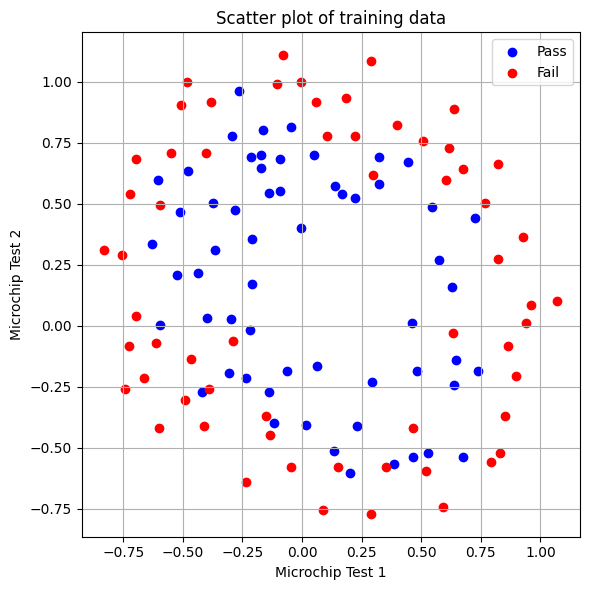


 SVM - linear kernel
Accuracy: 55.08%


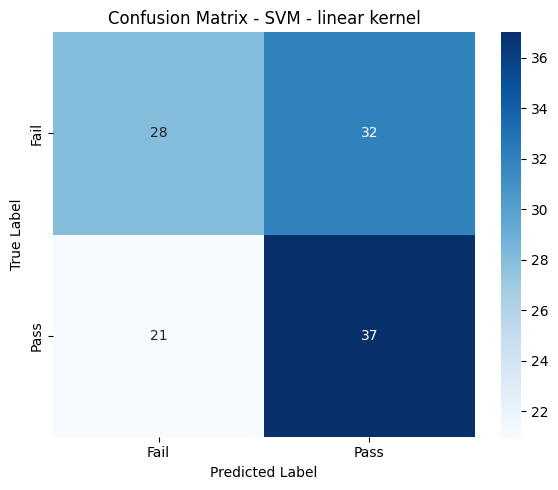

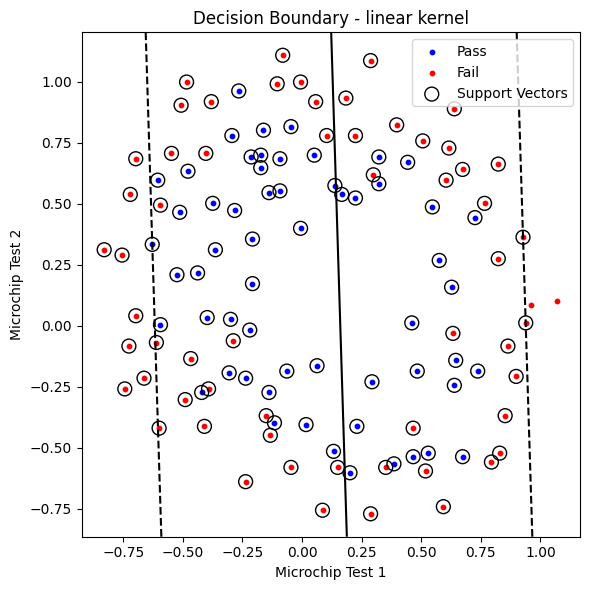


 SVM - poly kernel
Accuracy: 83.05%


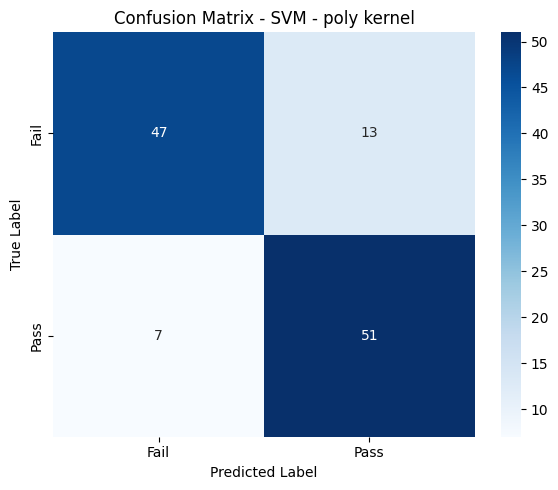

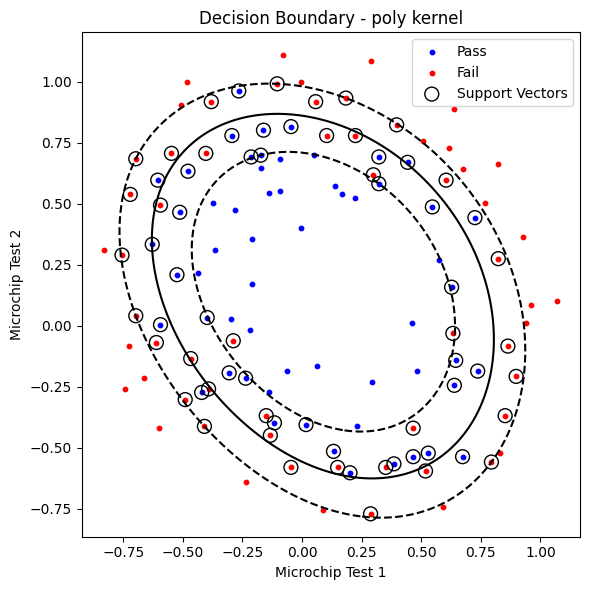


 SVM - rbf kernel
Accuracy: 81.36%


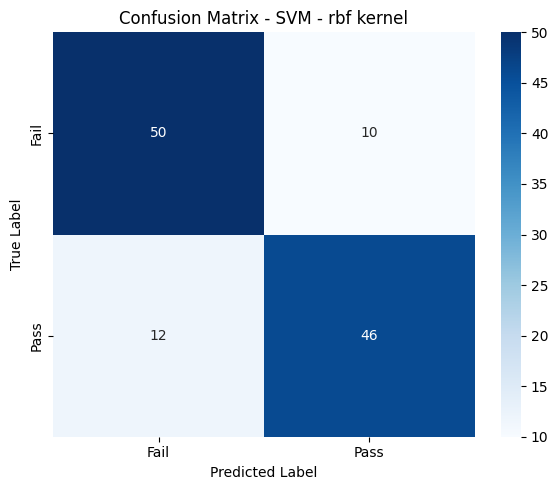

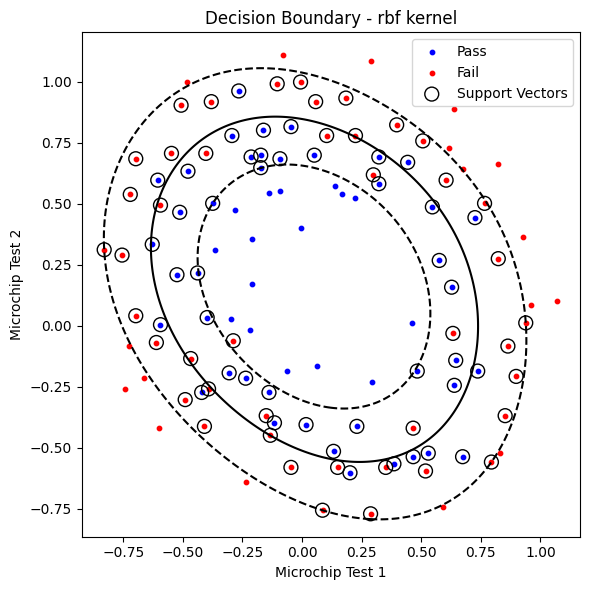


 SVM - sigmoid kernel
Accuracy: 25.42%


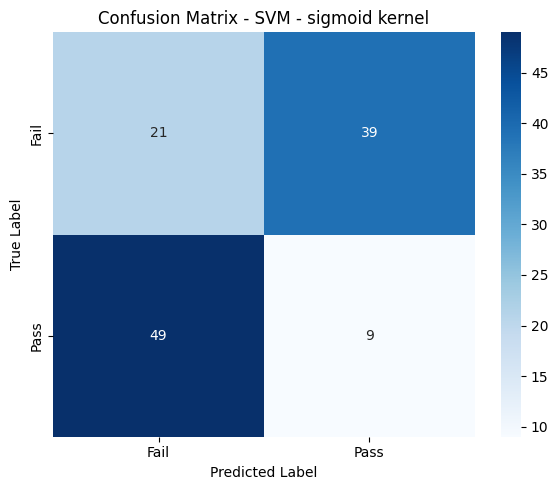

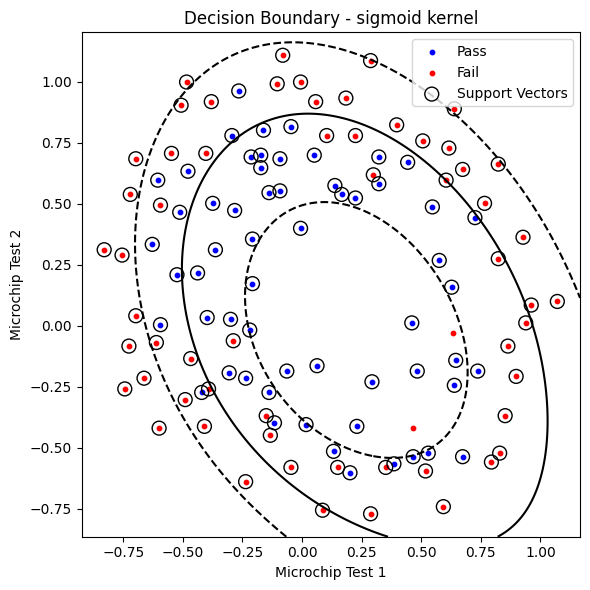

In [9]:

# Hàm đánh giá và vẽ ma trận nhầm lẫn
def evaluate_and_plot(y_true, y_pred, method_name=""):
    acc = accuracy_score(y_true.flatten(), y_pred)
    cm = confusion_matrix(y_true.flatten(), y_pred)

    print(f"\n {method_name}")
    print(f"Accuracy: {acc * 100:.2f}%")

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Fail', 'Pass'],
                yticklabels=['Fail', 'Pass'])
    plt.title(f'Confusion Matrix - {method_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

# Vẽ dữ liệu ban đầu
plt.figure(figsize=(6, 6))
mask = y == 1
plt.scatter(X[mask, 0], X[mask, 1], c='b', label='Pass')
plt.scatter(X[~mask, 0], X[~mask, 1], c='r', label='Fail')
plt.xlabel('Microchip Test 1')
plt.ylabel('Microchip Test 2')
plt.legend()
plt.title('Scatter plot of training data')
plt.grid(True)
plt.tight_layout()
plt.show()

# Danh sách các kernel cần kiểm tra
kernels = ['linear', 'poly', 'rbf', 'sigmoid']

for kernel in kernels:
    clf = svm.SVC(kernel=kernel, gamma=1, coef0=1)
    clf.fit(X, y)
    y_pred = clf.predict(X)
    evaluate_and_plot(y, y_pred, method_name=f"SVM - {kernel} kernel")

    # Vẽ biên phân lớp
    plt.figure(figsize=(6, 6))
    plt.scatter(X[mask, 0], X[mask, 1], c='b', label='Pass', s=10)
    plt.scatter(X[~mask, 0], X[~mask, 1], c='r', label='Fail', s=10)
    plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
                facecolors='none', edgecolors='k', s=100, label='Support Vectors')

    xlim = plt.xlim()
    ylim = plt.ylim()

    XX, YY = np.meshgrid(np.linspace(*xlim, 200),
                         np.linspace(*ylim, 200))
    Z = clf.decision_function(np.c_[XX.ravel(), YY.ravel()])
    Z = Z.reshape(XX.shape)

    plt.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1],
                linestyles=['--', '-', '--'])
    plt.title(f'Decision Boundary - {kernel} kernel')
    plt.xlabel('Microchip Test 1')
    plt.ylabel('Microchip Test 2')
    plt.legend()
    plt.tight_layout()
    plt.show()


# Bài tập tự thực hành 1

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import svm
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler

# Đường dẫn dữ liệu
file_path = '/content/drive/MyDrive/Classroom/MachineLearning/Lab12/ARgenderTrain.txt'

# Đọc dữ liệu từ file
data = pd.read_csv(file_path, header=None)

# Giả sử cột cuối là nhãn (0 hoặc 1), các cột trước là đặc trưng
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# Hàm đánh giá và vẽ ma trận nhầm lẫn
def evaluate_and_plot(y_true, y_pred, method_name=""):
    acc = accuracy_score(y_true.flatten(), y_pred)
    cm = confusion_matrix(y_true.flatten(), y_pred)

    print(f"\n {method_name}")
    print(f"Accuracy: {acc * 100:.2f}%")

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Female', 'Male'],
                yticklabels=['Female', 'Male'])
    plt.title(f'Confusion Matrix - {method_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

# Danh sách các kernel
kernels = ['linear', 'poly', 'rbf', 'sigmoid']

for kernel in kernels:
    clf = svm.SVC(kernel=kernel, gamma='scale', coef0=1)
    clf.fit(X_scaled, y)
    y_pred = clf.predict(X_scaled)
    evaluate_and_plot(y, y_pred, method_name=f"SVM - {kernel} kernel")

# Bài tập tự thực hành 2

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

# Đọc dữ liệu
data_path = '/content/drive/MyDrive/Classroom/MachineLearning/Lab12/dataset.csv'
dataset = pd.read_csv(data_path)

# Đầu vào và nhãn
X = dataset.iloc[:, :-1].values  # Age, EstimatedSalary
y = dataset.iloc[:, -1].values   # Purchased

# Chia tập train và test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

# Chuẩn hóa dữ liệu
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)


 SVM - linear kernel
Accuracy: 90.00%


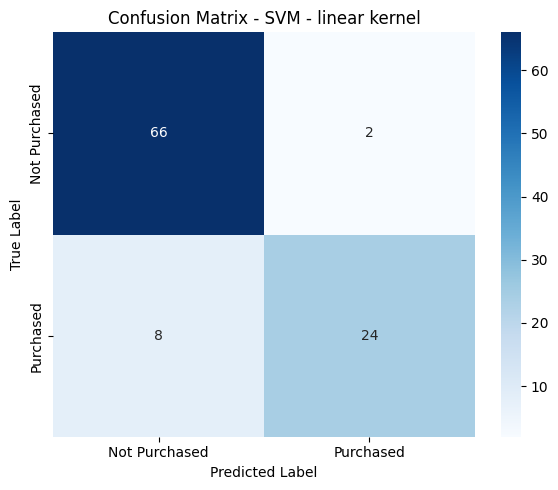


 SVM - poly kernel
Accuracy: 93.00%


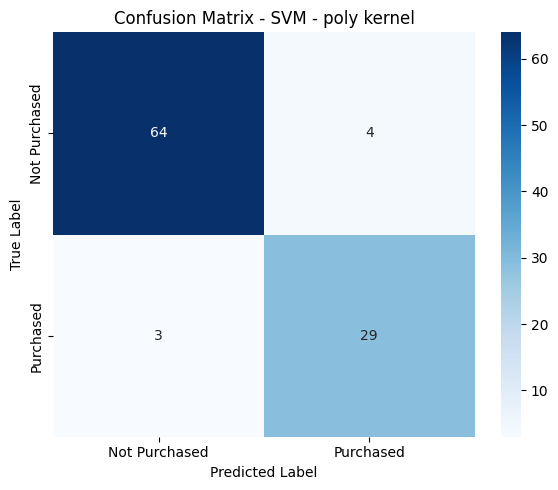


 SVM - rbf kernel
Accuracy: 93.00%


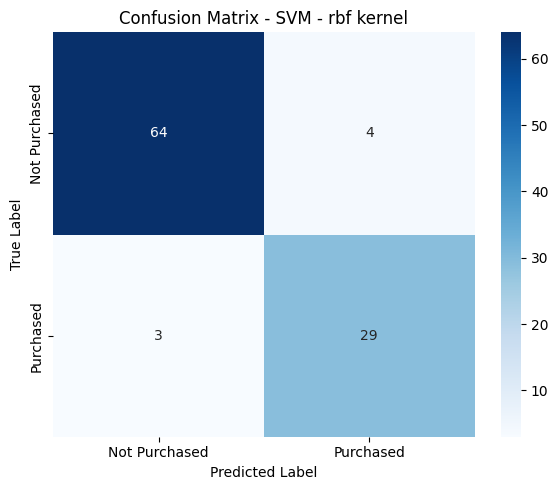


 SVM - sigmoid kernel
Accuracy: 71.00%


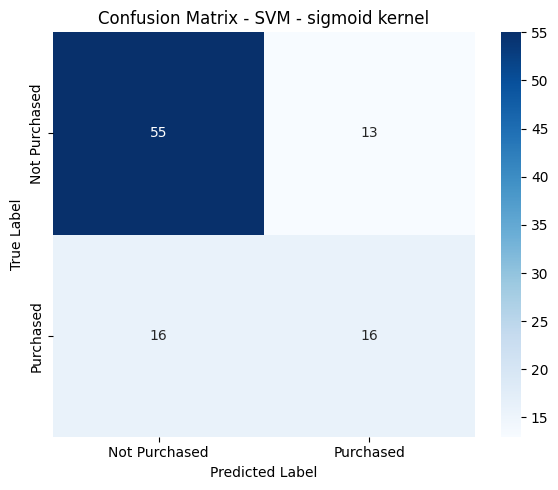

In [17]:
# Hàm đánh giá và vẽ ma trận nhầm lẫn
def evaluate_and_plot(y_true, y_pred, method_name=""):
    acc = accuracy_score(y_true.flatten(), y_pred)
    cm = confusion_matrix(y_true.flatten(), y_pred)

    print(f"\n {method_name}")
    print(f"Accuracy: {acc * 100:.2f}%")

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Not Purchased', 'Purchased'],
                yticklabels=['Not Purchased', 'Purchased'])
    plt.title(f'Confusion Matrix - {method_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

# Danh sách kernel
kernels = ['linear', 'poly', 'rbf', 'sigmoid']

# Huấn luyện và đánh giá mô hình
for kernel in kernels:
    clf = svm.SVC(kernel=kernel, gamma='scale', coef0=1)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    evaluate_and_plot(y_test, y_pred, method_name=f"SVM - {kernel} kernel")

# Bài tập tự thực hành 3

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import svm
from sklearn.metrics import accuracy_score, confusion_matrix

# Tải và khám phá dữ liệu
data = load_breast_cancer()
X = data.data
y = data.target  # 0 = malignant, 1 = benign

# In thông tin dữ liệu (tuỳ chọn)
print("Feature names:", data.feature_names)
print("Target names:", data.target_names)

# Chia dữ liệu thành train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

# Chuẩn hoá dữ liệu
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Feature names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
Target names: ['malignant' 'benign']



 SVM - linear kernel
Accuracy: 97.20%


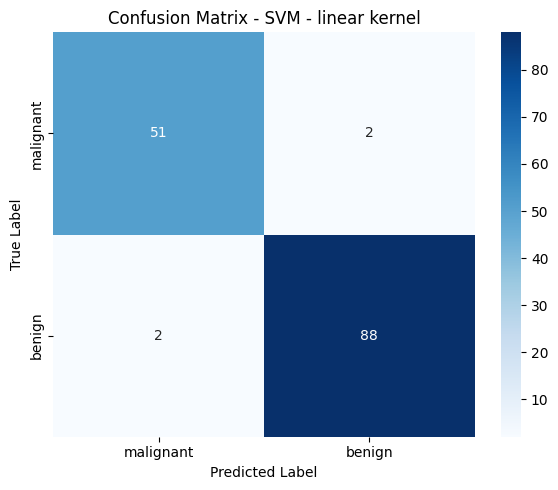


 SVM - poly kernel
Accuracy: 97.20%


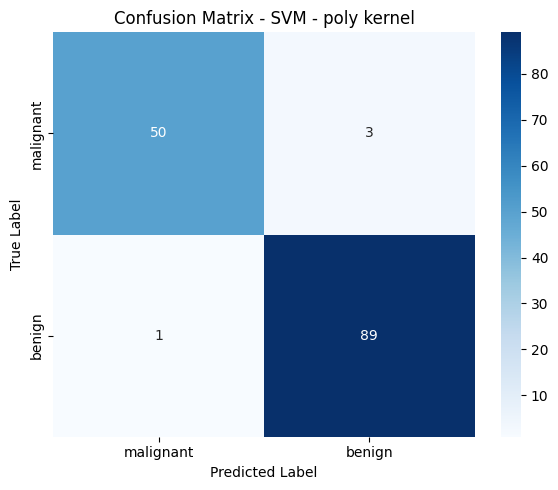


 SVM - rbf kernel
Accuracy: 96.50%


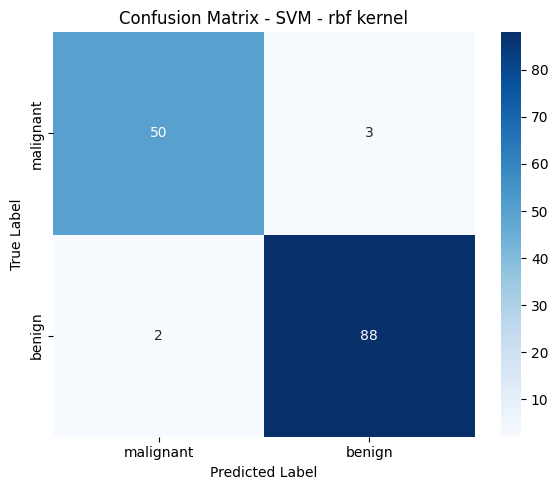


 SVM - sigmoid kernel
Accuracy: 90.21%


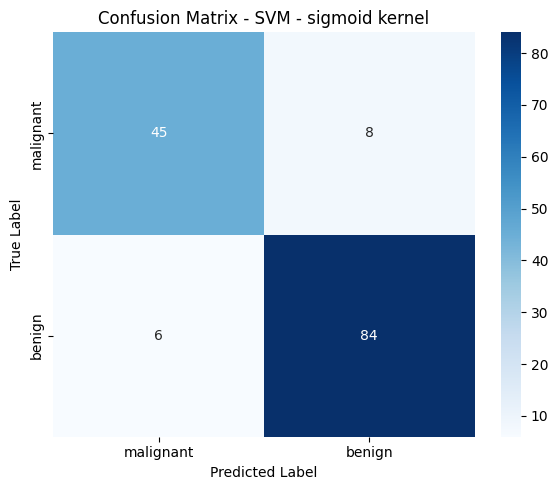

In [19]:
# Hàm đánh giá và hiển thị ma trận nhầm lẫn
def evaluate_and_plot(y_true, y_pred, method_name=""):
    acc = accuracy_score(y_true.flatten(), y_pred)
    cm = confusion_matrix(y_true.flatten(), y_pred)

    print(f"\n {method_name}")
    print(f"Accuracy: {acc * 100:.2f}%")

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=data.target_names,
                yticklabels=data.target_names)
    plt.title(f'Confusion Matrix - {method_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

# Danh sách các kernel
kernels = ['linear', 'poly', 'rbf', 'sigmoid']

# Huấn luyện và đánh giá mô hình theo từng kernel
for kernel in kernels:
    clf = svm.SVC(kernel=kernel, gamma='scale', coef0=1)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    evaluate_and_plot(y_test, y_pred, method_name=f"SVM - {kernel} kernel")